# HW2: Word2Vector
## Start

In [1]:
%run CBOW.ipynb
# start word2vec train process from here
txt_path = "data/"
save_vec_path = "model/word2vec/"
save_model_path = "model/"
zh_stop_path = "data/hit_stopwords.txt"
train_path = "data/train/"

In [2]:
# load text
zh_text = load_data(txt_path, version='zh')
# create words
zh_corpus = preprocess_text(zh_text, zh_stop_path=zh_stop_path, language='zh')
# create vocab
zh_vocab = build_vocab(zh_corpus)

In [3]:
# create training data
zh_train_data = create_training_data(zh_corpus, zh_vocab, window_size=5)
torch.save(zh_train_data, train_path+"zh_train_data.pth")
# load training data
zh_train_data = torch.load(train_path+"zh_train_data.pth")
zh_idx2word = {v:k for k,v in zh_vocab.items()}
print(zh_train_data[0], '\n', [zh_idx2word.get(idx) for idx in zh_train_data[0][0]], '\n', zh_idx2word.get(zh_train_data[0][1]))

([113, 734, 253, 4290, 4291, 734, 1566, 2779, 1566, 6104], 6103) 
 ['目前', '粮食', '出现', '阶段性', '过剩', '粮食', '换', '森林', '换', '草地'] 
 恰好


D:\workdata\software\TEMP\USERTEMP\ipykernel_23248\1791932877.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  zh_train_data = torch.load(train_path+"zh_train_data.pth")


In [4]:
# train zh model
model_zh = CBOW(vocab_size=len(zh_vocab), embedding_size=200).to(device)
# optimizer & loss function
optimizer, criterion = get_optim_and_loss(model_zh, "SGD", "cross")
print(model_zh, optimizer, criterion)

CBOW(
  (embedding): Embedding(12959, 200)
  (fc1): Linear(in_features=200, out_features=12959, bias=True)
) SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    momentum: 0.9
    nesterov: False
    weight_decay: 0
) CrossEntropyLoss()


In [5]:
epochs = 600
# set train mode
model_zh.train()
# start train
lossv_zh = []
print('Start zh training...')
train(model_zh, zh_train_data, optimizer, criterion, epochs, lossv_zh, batch_size=32)

Start zh training...


100%|██████████| 1284/1284 [00:01<00:00, 646.41it/s]


epoch 0, loss: 0.295878964902143


100%|██████████| 1284/1284 [00:02<00:00, 558.27it/s]


epoch 100, loss: 0.22252695741505538


...

epoch 400, loss: 0.16021878273002452


100%|██████████| 1284/1284 [00:01<00:00, 682.36it/s]


epoch 500, loss: 0.14615968684092753


100%|██████████| 1284/1284 [00:04<00:00, 315.65it/s]

Training finished


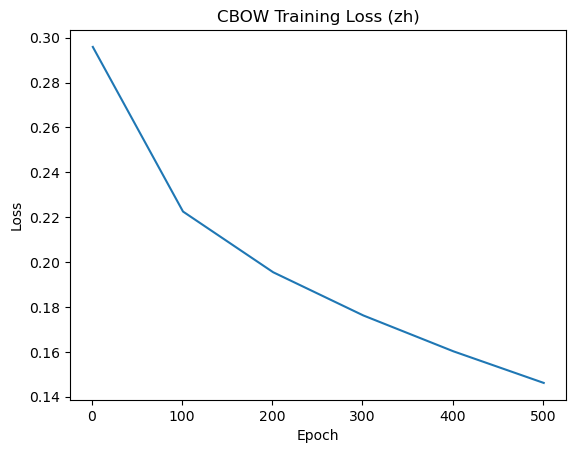

In [6]:
# plot 
plt.plot([epoch+1 for epoch in range(0, epochs, 100)], lossv_zh)
plt.title('CBOW Training Loss (zh)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

In [7]:
# save
save_model(model_zh, save_model_path, version='zh')
save_word_vectors(model_zh, zh_vocab, save_vec_path, version='zh')

## 7. An Example Task to Use Trained Word Vectors
### Compute similarity among words

In [11]:
# load word vectors
word_vectors_zh = load_word_vectors(save_vec_path, version="zh")

top_n = 3
zh_word = "人民"
# chinese
top_similarities_zh = find_similar_words(zh_word, word_vectors_zh, top_n)
print(f"Most similar top {top_n} words to '{zh_word}':")
for word, similarity in top_similarities_zh:
    print(f"{word}: {similarity:.3f}")

Most similar top 3 words to '人民':
涵盖: 1.324
主管们: 1.258
百分之三点三: 1.243


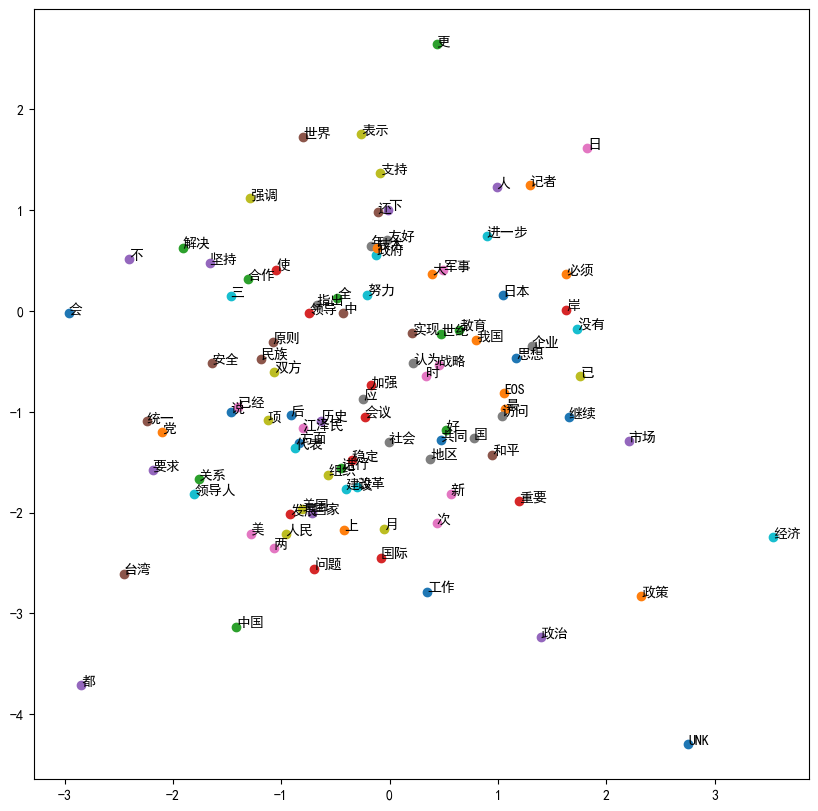

In [9]:
# plot
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
principalComponents = pca.fit_transform(model_zh.embedding.weight.cpu().detach().numpy())

word2ReduceDimensionVec = {}
for word in zh_vocab.keys():
    word2ReduceDimensionVec[word] = principalComponents[zh_vocab[word], :]
    
plt.figure(figsize=(10, 10))
count = 0
for word, wordvec in word2ReduceDimensionVec.items():
    if count < 100:
        plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
        plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号，否则负号会显示成方块
        plt.scatter(wordvec[0], wordvec[1])
        plt.annotate(word, (wordvec[0], wordvec[1]))
        count += 1
plt.show()